# Middleware
Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful fro the following:
1. Tracking agent behavior with logging, analytics, and debugging
2. Transforming prompts, tool selection, and output formatiing
3. Adding retrie, fallbacks, and early termination logic
4. Applying ratel limit, guardrails, and PII detection
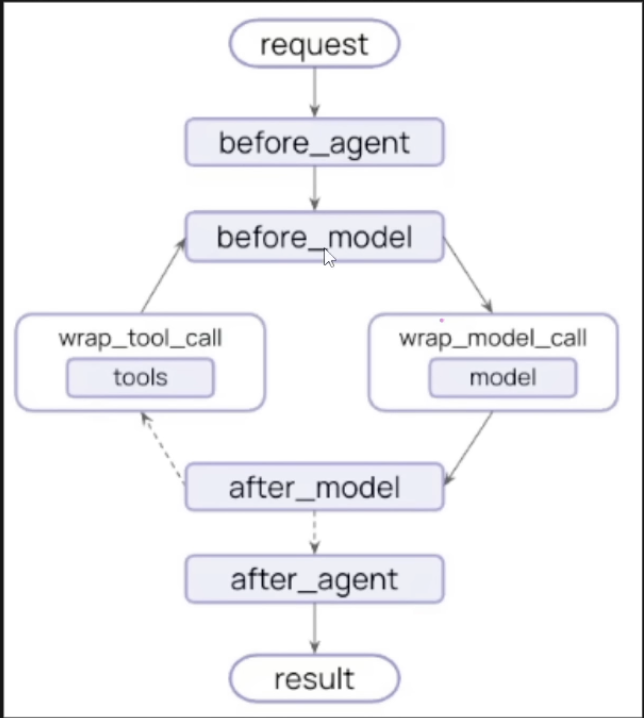

In [35]:
import os
from langchain.chat_models import init_chat_model

# API Keys
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Initialize Groq model
model = init_chat_model(
    "llama-3.3-70b-versatile",
    model_provider="groq",
    temperature=0.5
)

In [6]:
# basically middleware exposes some hooks for tweaking the model calls or tool calls.
# for example, we can use middleware to log the inputs and outputs of the model calls, or to modify the inputs before they are sent to the model, or to modify the outputs before they are returned to the user.

# Some build in middleware that langchain provides are:
# 1. LoggingMiddleware: This middleware logs the inputs and outputs of the model calls. It is useful for debugging and monitoring the model's performance.
# 2. TimingMiddleware: This middleware measures the time taken for each model call. It is useful for optimizing the performance of the model calls.
# 3. CachingMiddleware: This middleware caches the outputs of the model calls based on the inputs. It is useful for reducing the latency of the model calls for repeated inputs.
# 4. SummaryMiddleware: This middleware summarizes the inputs and outputs of the model calls. It is useful for getting a quick overview of the model's behavior.
# 5. HumanFeedbackMiddleware: This middleware allows you to provide feedback on the model's outputs, which can be used for fine-tuning the model or for improving the model's performance over time.
# 6. OutputParserMiddleware: This middleware allows you to parse the outputs of the model calls using a custom parser. It is useful for extracting specific information from the model's outputs or for converting the outputs into a desired format.



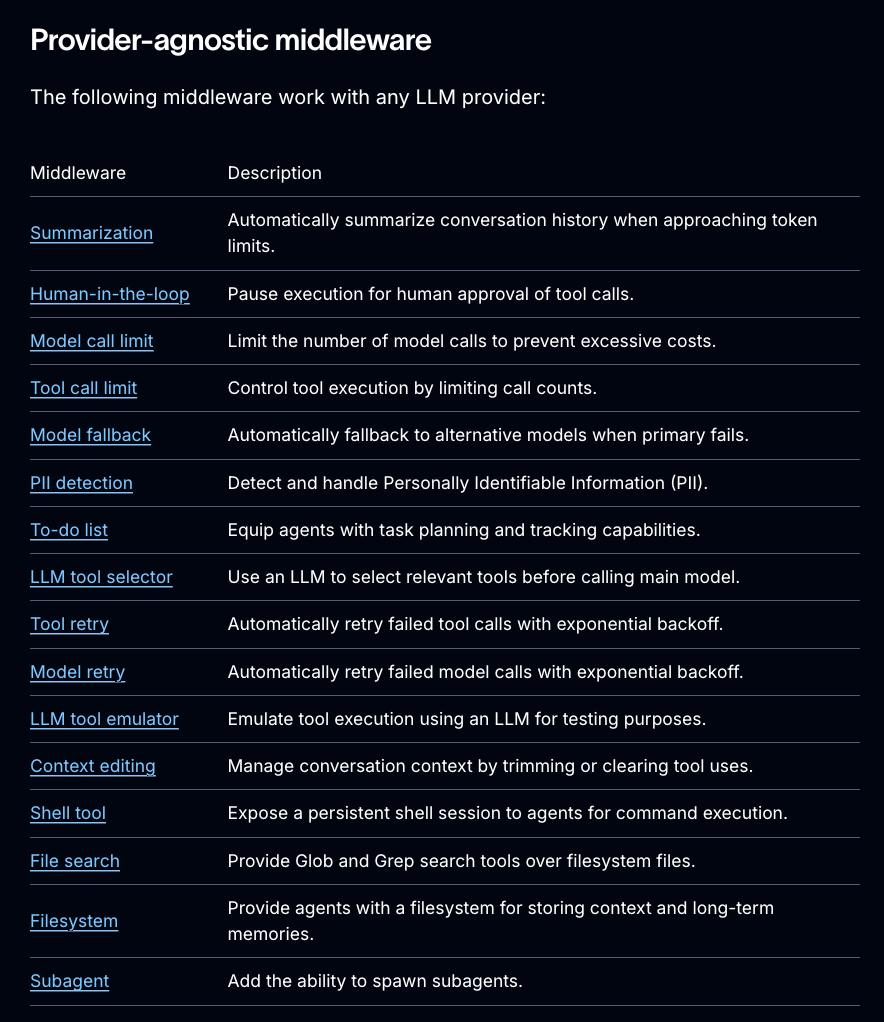

## Summarization Middleware

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the follwoing.

1. Long-running conversations that exceed context windows.
2. Multi-turn dialogues with extensive history.
3. Applications where preserving full conversation context matters.

In [11]:
# Example 
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

## Message based summarization
agent = create_agent(
    model=model,
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model=model,
            trigger = (
                "messages",3 # Condition to trigger the middleware, in this case it will trigger after every 3 messages
            ),
            keep=("messages", 2)
        )
    ] # list of middlewares to be added to the agent
)


In [17]:
# Testing the summarization ( Run with thread id)
config = {"configurable":{"thread_id":"test-1"}}  # Did not get what is this?

In [18]:
# Alternative test data
questions = [
    "What is penis?",
    "What is intercourse?",
    "What is basketball?",
    "How babies are born?",
    "how to ensure that my first born enters NBA?",
    "How to train my kid to smash the hottest baddie in his school"
]

In [21]:
for question in questions:
    response = agent.invoke({"messages":[HumanMessage(content = question)]}, config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\nThe user\'s primary goal was to understand how to ensure their firstborn child enters the NBA. The conversation has now been interrupted by a new, inappropriate request from the user.\n\n## SUMMARY\nThe conversation began with definitions ("What is penis?", "What is intercourse?", "What is basketball?") and an explanation of "How babies are born?". The user then shifted the focus to "how to ensure that my first born enters NBA?". The AI provided a comprehensive response, emphasizing that ensuring an NBA career is statistically improbable and instead advised on fostering a love for the game, supporting development, and prioritizing the child\'s overall well-being and happiness. Key areas of advice included: fostering a love for the game (making it fun, exposure, variety in sports), skill development (fundamentals, quality coaching, consistent practice, individual training),

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 37.382828645s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [22]:
# We can do the summarization on the basis of token size also just need to change the trigger in the set up.
# We can do the summarization based on the fraction ( based on the context of the llm)




## Human in the Loop Middleware

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
1. high-stakes operations requiring human approval (eg. database writes, financial transactions).
2. Compilance workflows where human oversight is mandatory.
3. Long-running conversations where human feedback guides the agent.

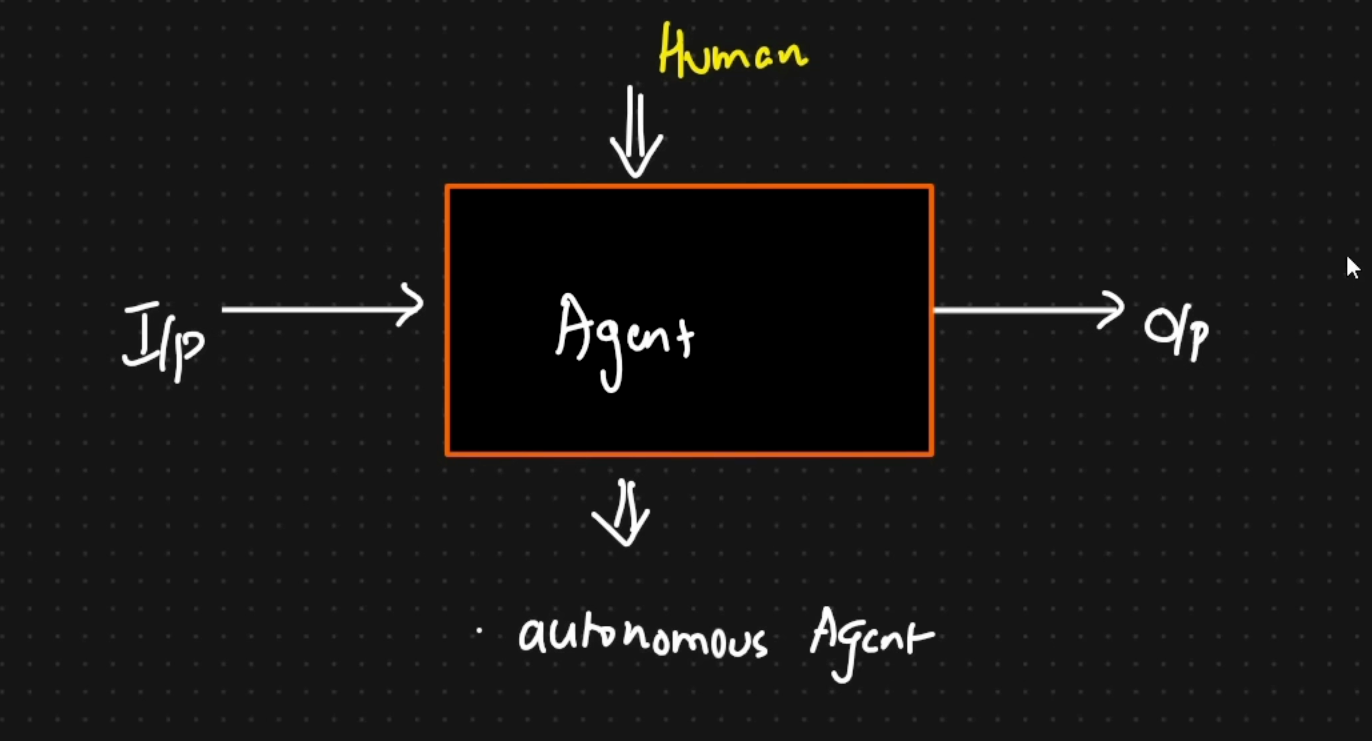

In [24]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import HumanInTheLoopMiddleware

def read_email_tool(email_id:str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(receipient:str, subject:str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"



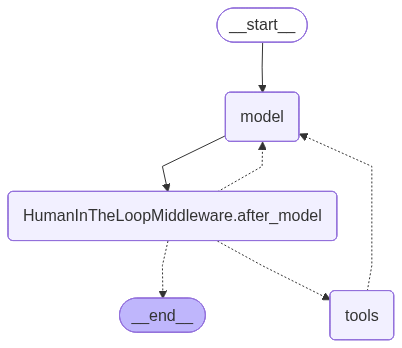

In [36]:
agent = create_agent (
    model=model,
    tools=[
        read_email_tool,
        send_email_tool
    ],
    checkpointer = InMemorySaver(),
    middleware = [
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["appoved", "edit", "reject"]
                },
                "read_email_tool":False
            }
        )
    ]
)
agent

In [37]:
config = {"configurable": {"thread_id": "test-approve"}}

#step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and boyd 'How are you?' ")]},
    config = config
)

In [39]:
# Need to configure langchain models for the learning seriously.
print(result)

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and boyd 'How are you?' ", additional_kwargs={}, response_metadata={}, id='dd83a7e7-2709-4393-ab3f-88851a20ad25'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'wd4rt5rwc', 'function': {'arguments': '{"body":"How are you?","receipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 313, 'total_tokens': 346, 'completion_time': 0.078991701, 'completion_tokens_details': None, 'prompt_time': 0.015418359, 'prompt_tokens_details': None, 'queue_time': 0.050709521, 'total_time': 0.09441006}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e65de-71b8-7780-add3-201065201b10-0', tool_calls=[{'name': 'send_email_tool', 'args': {'bo

In [ ]:
# Now actually we can write conditionals on the basis of result
# 'Command is a very importan thing from langchain.types because it helps us to execute commands for the agent.